**UPLOAD** **DATASET**

In [23]:
from google.colab import files
uploaded = files.upload()

Saving bank.csv.xlsx to bank.csv (2).xlsx


**IMPORT** **LIBRARIES**

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

**LOAD** **DATASET**

In [25]:
df = pd.read_excel('bank.csv.xlsx')
# The Excel file appears to have data in a single column, semicolon-separated.
# Let's split this column into multiple columns and assign appropriate headers.
# Assuming the first row of the original output is the header.
column_names = df.columns[0].replace('"', '').split(';')

# Split the single column into multiple columns using ';' as delimiter
df_split = df.iloc[:, 0].str.replace('"', '').str.split(';', expand=True)

# Assign the extracted column names to the new DataFrame
df_split.columns = column_names

# The first row of df_split will contain the actual first row of data, as the original column headers were used to name the columns.
# So, df_split is the correctly structured DataFrame.
df = df_split
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


**DATA** **PREPROCESSING**

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   object
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   object
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   object
 10  month      4521 non-null   object
 11  duration   4521 non-null   object
 12  campaign   4521 non-null   object
 13  pdays      4521 non-null   object
 14  previous   4521 non-null   object
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: object(17)
memory usage: 600.6+ KB


**CONVERT** **CATEGORICAL** **DATA** **INTO** - **NUMERIC**

In [27]:
le = LabelEncoder()

for col in df.columns:
  if df[col].dtype == 'object':
    df[col] = le.fit_transform(df[col])

print(le)

LabelEncoder()


**DEFINE** **TARGETS** **AND** **FEATURES**

In [28]:
x= df.drop ('y', axis=1)
y = df['y']

**TRAIN**-**TEST** **SPLIT**

In [29]:
x_train,x_test,y_train,y_test = train_test_split(
    x,y,test_size=0.2,random_state=42
)

**BUILD** **DECISION** **TREE** **MODEL**

In [30]:
model=DecisionTreeClassifier(
    criterion='entropy',max_depth=5,random_state=42
)
model.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

**MAKE** **PREDICTIONS**

In [31]:
y_pred = model.predict(x_test)

In [32]:
print("accuracy:",accuracy_score(y_test,y_pred))
print("\nClassification Report:\n",classification_report(y_test,y_pred))
print("\nConfusion Matrix:\n",confusion_matrix(y_test,y_pred))


accuracy: 0.8906077348066298

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.99      0.94       807
           1       0.47      0.08      0.14        98

    accuracy                           0.89       905
   macro avg       0.68      0.54      0.54       905
weighted avg       0.85      0.89      0.85       905


Confusion Matrix:
 [[798   9]
 [ 90   8]]


**VISUALISE** **DECISION** **TREE**

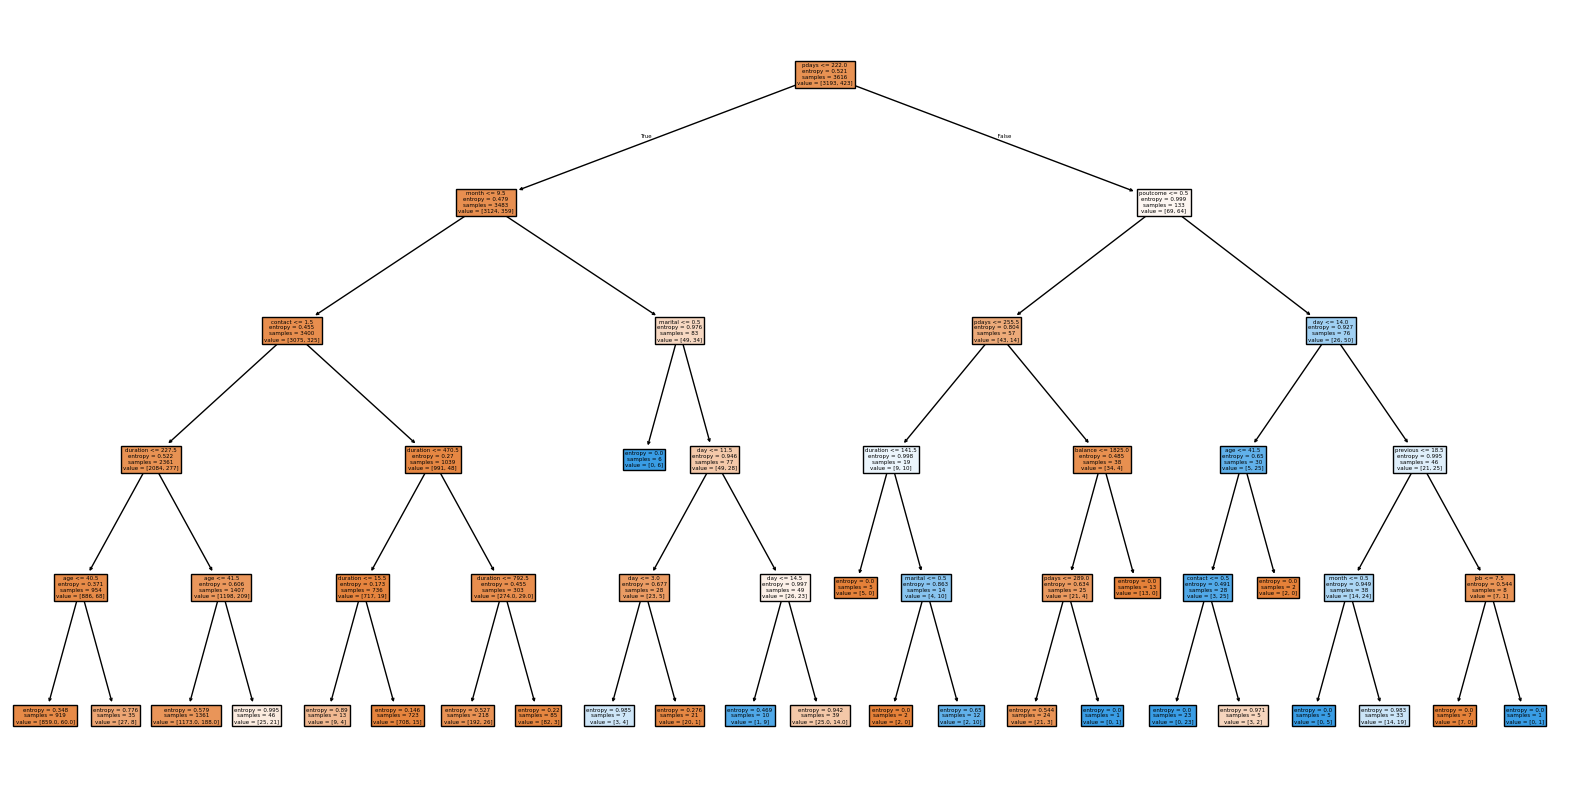

In [33]:
plt.figure(figsize=(20,10))
plot_tree(model,filled=True,feature_names=x.columns)
plt.show()

**IMPROVING** **MODEL** **ACCURACY**

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(x_train, y_train)

print("Random Forest Accuracy:", rf.score(x_test, y_test))

Random Forest Accuracy: 0.8961325966850828
